# TPC-DS Workload Generator Comparison
Reference workload: `tpcds` (the 99 hand-written TPC-DS queries).
Target system under evaluation: **`gpt_generated_100_tpcds`**.

Two axes are evaluated separately, because a generator can score well on one and badly on the other:

1. **Fidelity** — how closely the generated workload's structural statistics track the real TPC-DS distribution.
2. **Diversity** — how much non-redundant plan/operator structure the workload actually explores.

Place `tpcds_baseline_diversity_comparison.csv` next to this notebook.

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
})

CSV  = "results/tpcds_baseline_diversity_comparison_100.csv"
REF  = "tpcds"                    # ground-truth workload
MINE = "gpt_generated_100_tpcds"        # system under evaluation

df = pd.read_csv(CSV).copy()
df["w"] = df["workload"]
df = df.set_index("w")
GENS = [w for w in df.index if w != REF]

# consistent colours: mine highlighted, baselines muted, reference black
COL = {g: "#b8b8b8" for g in GENS}
COL[MINE] = "#c2410c"
COL[REF]  = "#111111"
ORDER = [MINE] + [g for g in GENS if g != MINE]
df.shape

## 1. Fidelity — relative error against real TPC-DS
For every `meta_<feature>_mean`, compute `|gen - real| / real`. Lower is closer to the real workload.

In [16]:
mean_cols = [c for c in df.columns if c.startswith("meta_") and c.endswith("_mean")]
real = df.loc[REF, mean_cols].astype(float)
rel  = (df.loc[GENS, mean_cols].astype(float) - real).abs().div(real.replace(0, np.nan))
rel.columns = [c.replace("meta_num_", "").replace("meta_", "").replace("_mean", "") for c in rel.columns]

fidelity = rel.mean(axis=1).sort_values()          # mean absolute relative error (MARE)
fidelity.rename("MARE").to_frame().style.format("{:.3f}")

,MARE
w,
gpt_generated_100_tpcds,0.603
bootstrapping_lcm_tpcds,0.691
sql_factory_tpcds,0.709
sqlbarber_tpcds,0.750
e2etune_tpcds,0.776
sqlstorm_tpcds,1.018


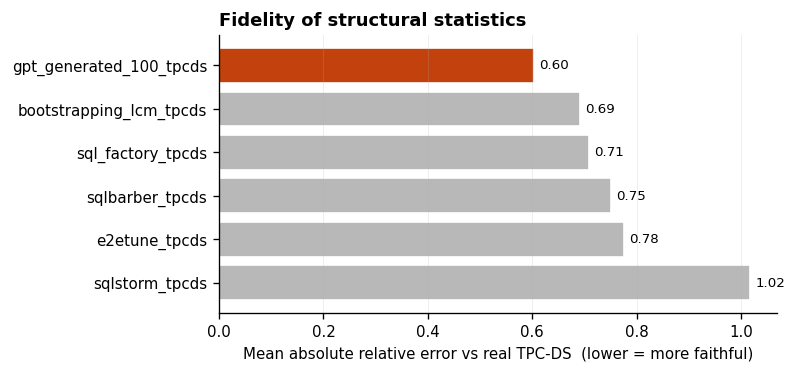

In [17]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(fidelity.index, fidelity.values,
        color=[COL[g] for g in fidelity.index], edgecolor="white")
for i, (g, v) in enumerate(fidelity.items()):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=8)
ax.set_xlabel("Mean absolute relative error vs real TPC-DS  (lower = more faithful)")
ax.set_title("Fidelity of structural statistics", loc="left", fontweight="bold")
ax.invert_yaxis(); ax.grid(axis="y", visible=False)
plt.show()

### Per-feature error heatmap
Where does each generator win or lose? Clipped at 2.0 so a few blow-ups don't wash out the colour scale.

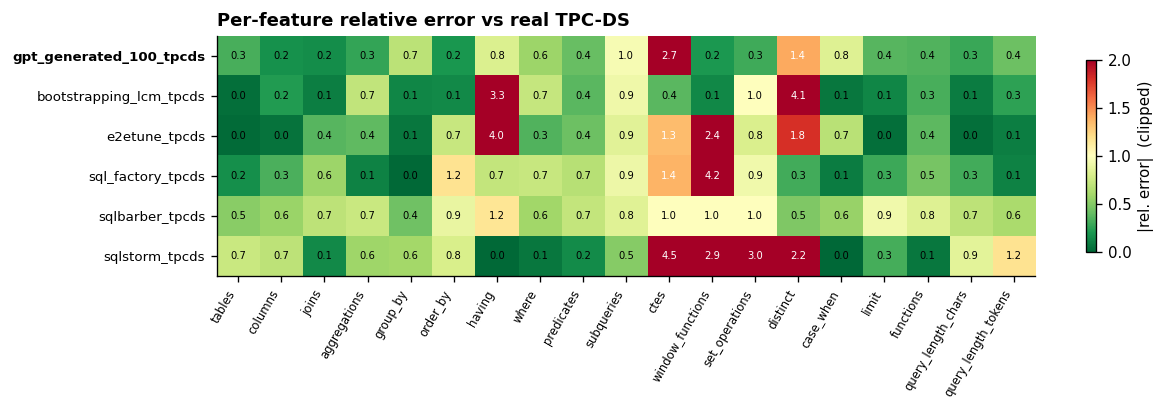

In [18]:
M = rel.loc[ORDER]
fig, ax = plt.subplots(figsize=(11, 2.6))
im = ax.imshow(M.values, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=2.0)
ax.set_xticks(range(M.shape[1])); ax.set_xticklabels(M.columns, rotation=60, ha="right", fontsize=7)
ax.set_yticks(range(M.shape[0])); ax.set_yticklabels(M.index, fontsize=8)
ax.get_yticklabels()[0].set_fontweight("bold")
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=6,
                    color="white" if v > 1.2 else "black")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="|rel. error|  (clipped)")
ax.set_title("Per-feature relative error vs real TPC-DS", loc="left", fontweight="bold")
plt.show()

## 2. Diversity — normalised profile
Each metric is min–max scaled across the six generators (1.0 = best generator on that metric). The real workload is overlaid as a reference line, *not* as a target ceiling.

In [19]:
DIV = ["table_coverage", "column_coverage", "join_edge_coverage",
       "complexity_weighted_table_coverage", "unique_table_set_ratio",
       "plan_graph_uniqueness_ratio", "plan_graph_vendi_score",
       "n_operator_types_observed", "operator_type_entropy",
       "unique_operator_instance_count", "unique_operator_ngram_count",
       "operator_ngram_entropy", "mean_nearest_neighbour_distance",
       "min_nearest_neighbour_distance", "meta_unique_skeleton_ratio",
       "meta_schema_table_coverage_pct"]

sub  = df.loc[GENS, DIV].astype(float)
norm = (sub - sub.min()) / (sub.max() - sub.min()).replace(0, np.nan)
ref_n = (df.loc[REF, DIV].astype(float) - sub.min()) / (sub.max() - sub.min()).replace(0, np.nan)

ranks = sub.rank(ascending=False).astype(int)
pd.DataFrame({"real_tpcds": df.loc[REF, DIV].astype(float),
              MINE: sub.loc[MINE],
              "rank_of_mine": ranks.loc[MINE],
              "best_generator": sub.idxmax(),
              "best_value": sub.max()}).round(3)

,real_tpcds,gpt_generated_100_tpcds,rank_of_mine,best_generator,best_value
table_coverage,1.000,1.000,2,bootstrapping_lcm_tpcds,1.000
column_coverage,0.581,0.508,3,e2etune_tpcds,0.685
join_edge_coverage,0.683,0.951,1,e2etune_tpcds,0.951
complexity_weighted_table_coverage,1.000,1.000,2,bootstrapping_lcm_tpcds,1.000
unique_table_set_ratio,0.657,0.850,2,e2etune_tpcds,0.990
plan_graph_uniqueness_ratio,0.848,1.000,1,e2etune_tpcds,1.000
plan_graph_vendi_score,22.261,27.192,2,sqlstorm_tpcds,30.656
n_operator_types_observed,29.000,25.000,4,sqlstorm_tpcds,29.000
operator_type_entropy,0.680,0.731,4,sql_factory_tpcds,0.767
unique_operator_instance_count,2739.000,2570.000,2,sqlstorm_tpcds,4047.000


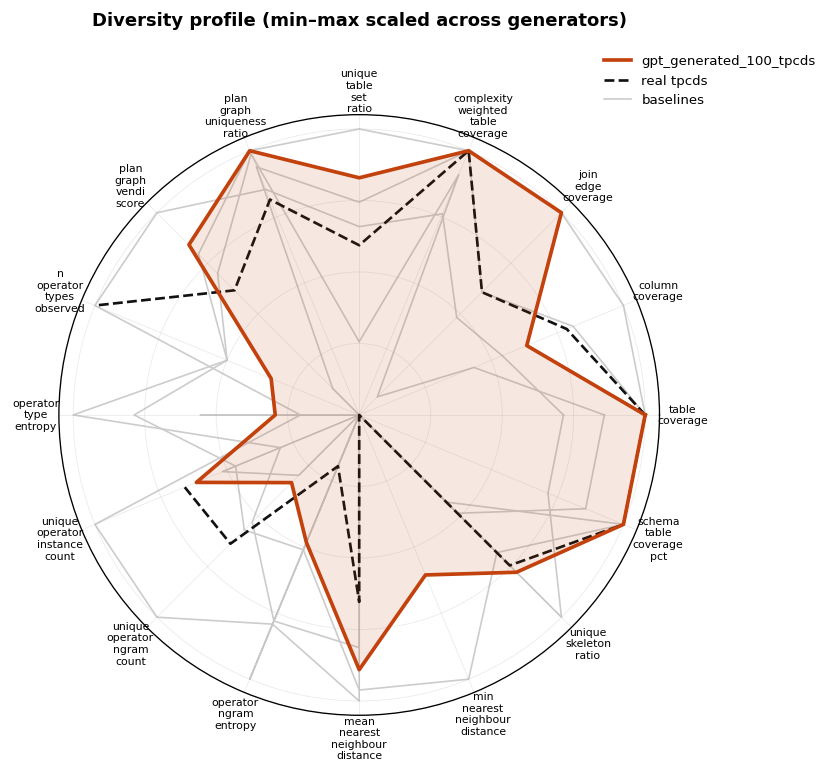

In [20]:
ang = np.linspace(0, 2*np.pi, len(DIV), endpoint=False).tolist(); ang += ang[:1]
labels = [d.replace("meta_", "").replace("_", "\n") for d in DIV]

fig, ax = plt.subplots(figsize=(6.5, 6.5), subplot_kw=dict(polar=True))
for g in GENS:
    if g == MINE: continue
    v = norm.loc[g].fillna(0).tolist(); v += v[:1]
    ax.plot(ang, v, color="#cccccc", lw=1, zorder=1)
v = ref_n.fillna(0).tolist(); v += v[:1]
ax.plot(ang, v, color=COL[REF], lw=1.6, ls="--", label="real tpcds", zorder=2)
v = norm.loc[MINE].fillna(0).tolist(); v += v[:1]
ax.plot(ang, v, color=COL[MINE], lw=2.2, label=MINE, zorder=3)
ax.fill(ang, v, color=COL[MINE], alpha=0.12, zorder=3)

ax.set_xticks(ang[:-1]); ax.set_xticklabels(labels, fontsize=6.5)
ax.set_yticks([0, .25, .5, .75, 1]); ax.set_yticklabels([]); ax.set_ylim(0, 1.05)
ax.legend(handles=[plt.Line2D([],[],color=COL[MINE],lw=2.2,label=MINE),
                   plt.Line2D([],[],color=COL[REF],lw=1.6,ls="--",label="real tpcds"),
                   plt.Line2D([],[],color="#cccccc",lw=1,label="baselines")],
          loc="upper right", bbox_to_anchor=(1.28, 1.12), frameon=False, fontsize=8)
ax.set_title("Diversity profile (min–max scaled across generators)", pad=26, fontweight="bold")
plt.show()

## 3. The money plot — diversity vs. fidelity
Upper-left is the desirable quadrant: plan-space diversity **without** drifting away from the real workload's structural distribution.

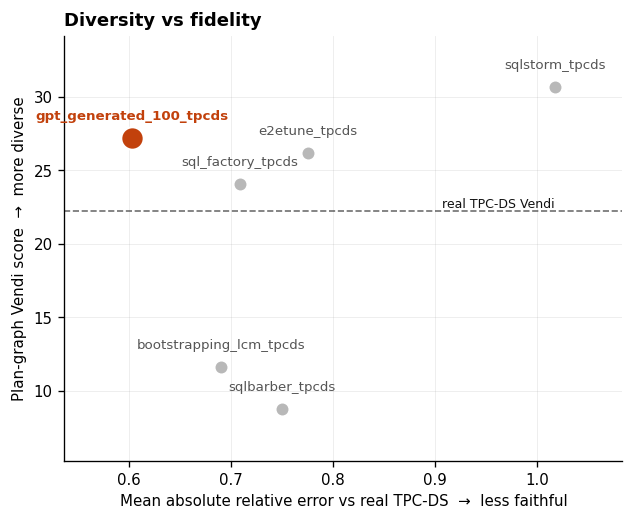

In [21]:
fig, ax = plt.subplots(figsize=(6, 4.6))
x = fidelity.reindex(GENS)
y = df.loc[GENS, "plan_graph_vendi_score"]

ax.axhline(df.loc[REF, "plan_graph_vendi_score"], color="#111", ls="--", lw=1, alpha=.6)
ax.text(x.max()*1.0, df.loc[REF, "plan_graph_vendi_score"], " real TPC-DS Vendi",
        va="bottom", ha="right", fontsize=7.5, color="#111")

for g in GENS:
    big = g == MINE
    ax.scatter(x[g], y[g], s=180 if big else 70, color=COL[g],
               edgecolor="white", lw=1.2, zorder=3 if big else 2)
    ax.annotate(g, (x[g], y[g]), textcoords="offset points", xytext=(0, 11),
                ha="center", fontsize=8, fontweight="bold" if big else "normal",
                color=COL[g] if big else "#555")

ax.set_xlabel("Mean absolute relative error vs real TPC-DS  →  less faithful")
ax.set_ylabel("Plan-graph Vendi score  →  more diverse")
ax.set_title("Diversity vs fidelity", loc="left", fontweight="bold")
ax.margins(0.16)
plt.show()

## 4. Complexity mix
Distance from the real low/medium/high split (13.1 / 73.7 / 13.1).

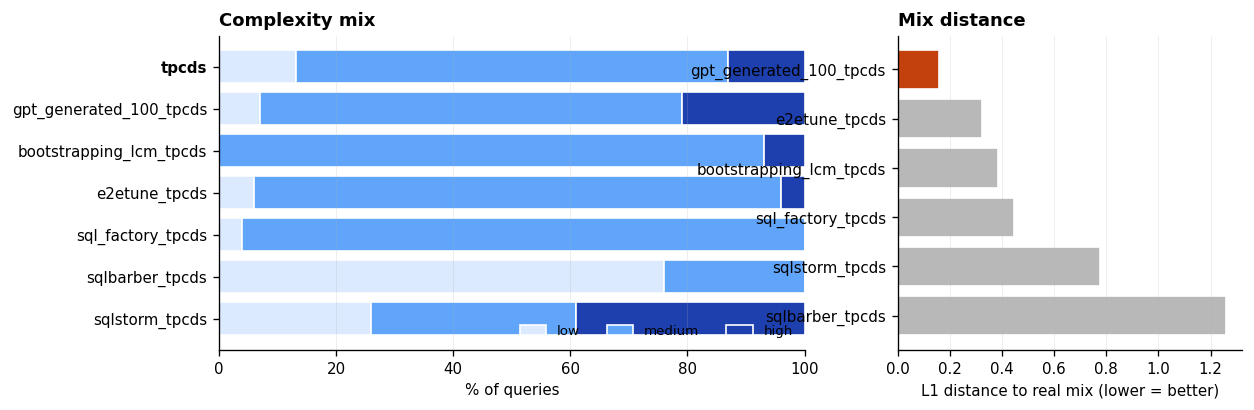

In [22]:
mix_c = ["meta_complexity_low_pct", "meta_complexity_medium_pct", "meta_complexity_high_pct"]
mix = df[mix_c] / 100
l1 = (mix.loc[GENS] - mix.loc[REF]).abs().sum(axis=1).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios": [1.7, 1]})
rows = [REF] + list(ORDER)
shades = ["#dbeafe", "#60a5fa", "#1e40af"]
left = np.zeros(len(rows))
for c, sh, lab in zip(mix_c, shades, ["low", "medium", "high"]):
    vals = mix.loc[rows, c].values * 100
    axes[0].barh(rows, vals, left=left, color=sh, label=lab, edgecolor="white")
    left += vals
axes[0].invert_yaxis(); axes[0].set_xlabel("% of queries"); axes[0].grid(axis="y", visible=False)
axes[0].legend(frameon=False, ncol=3, fontsize=8, loc="lower right")
axes[0].set_title("Complexity mix", loc="left", fontweight="bold")
axes[0].get_yticklabels()[0].set_fontweight("bold")

axes[1].barh(l1.index, l1.values, color=[COL[g] for g in l1.index], edgecolor="white")
axes[1].invert_yaxis(); axes[1].grid(axis="y", visible=False)
axes[1].set_xlabel("L1 distance to real mix (lower = better)")
axes[1].set_title("Mix distance", loc="left", fontweight="bold")
plt.show()

## 5. Range coverage
Does the generator span the *tails* of the real workload, or only its centre? Grey = real TPC-DS range; coloured bar = generator range.

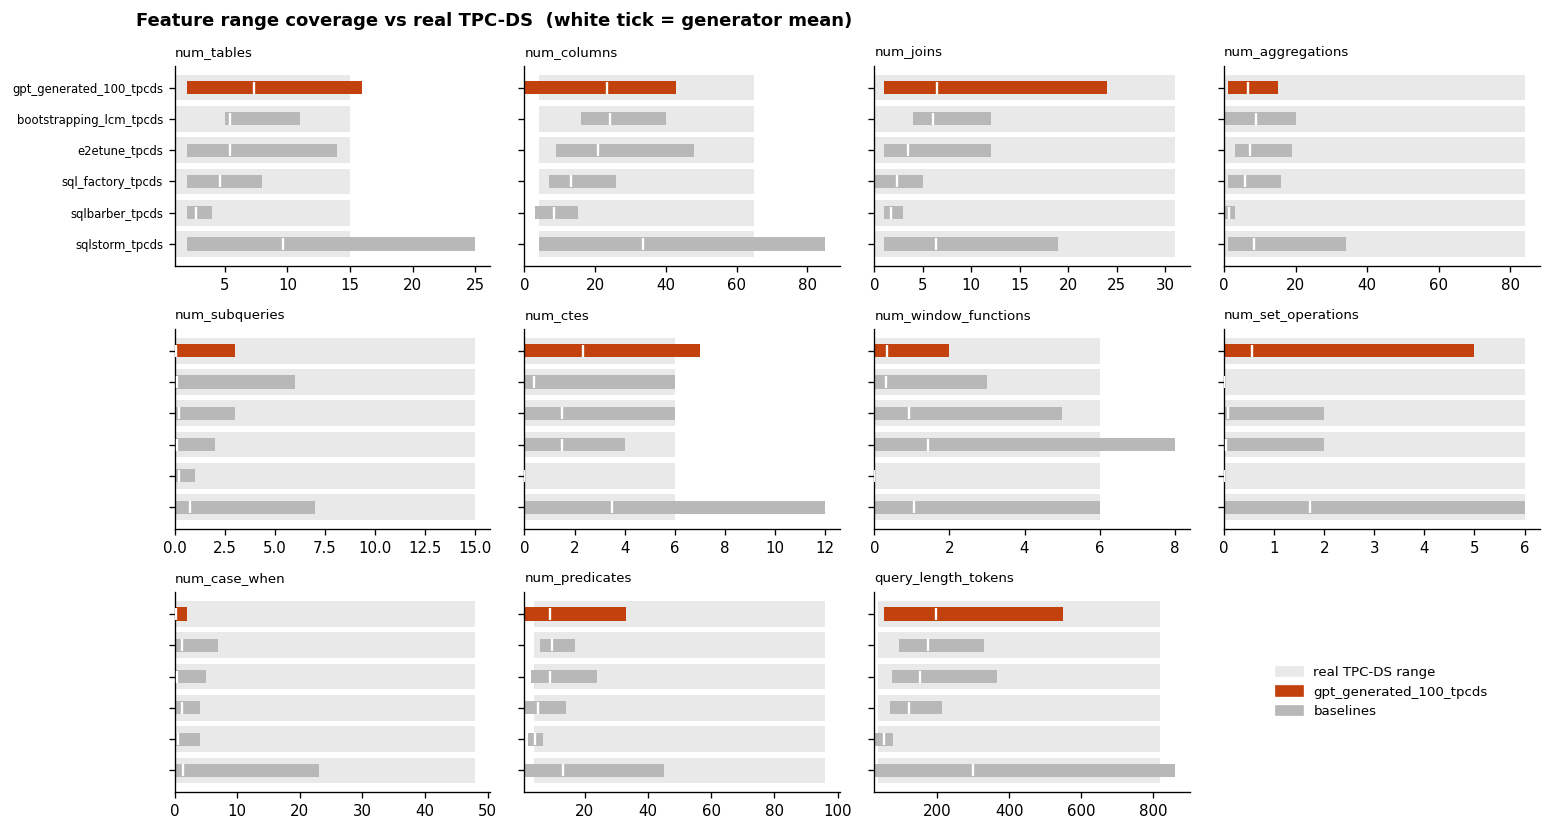

In [23]:
FEATS = ["num_tables", "num_columns", "num_joins", "num_aggregations", "num_subqueries",
         "num_ctes", "num_window_functions", "num_set_operations", "num_case_when",
         "num_predicates", "query_length_tokens"]

fig, axes = plt.subplots(3, 4, figsize=(13, 7))
for ax, f in zip(axes.ravel(), FEATS):
    lo, hi = df.loc[REF, f"meta_{f}_min"], df.loc[REF, f"meta_{f}_max"]
    ax.barh(range(len(ORDER)), [hi - lo] * len(ORDER), left=lo,
            color="#e9e9e9", height=0.82, zorder=1)
    for i, g in enumerate(ORDER):
        glo, ghi = df.loc[g, f"meta_{f}_min"], df.loc[g, f"meta_{f}_max"]
        ax.barh(i, max(ghi - glo, hi * 0.004), left=glo, color=COL[g], height=0.42, zorder=2)
        ax.plot(df.loc[g, f"meta_{f}_mean"], i, "|", color="white", ms=7, mew=1.4, zorder=3)
    ax.set_yticks(range(len(ORDER)))
    ax.set_yticklabels(ORDER if ax is axes[0, 0] else [], fontsize=7)
    ax.invert_yaxis(); ax.set_title(f, fontsize=8, loc="left"); ax.grid(False)
for ax in axes.ravel()[len(FEATS):]:
    ax.axis("off")
axes.ravel()[len(FEATS)].legend(
    handles=[Patch(color="#e9e9e9", label="real TPC-DS range"),
             Patch(color=COL[MINE], label=MINE), Patch(color="#b8b8b8", label="baselines")],
    loc="center", frameon=False, fontsize=8)
fig.suptitle("Feature range coverage vs real TPC-DS  (white tick = generator mean)",
             x=0.09, ha="left", fontweight="bold")
plt.tight_layout(); plt.show()

## 6. Plan redundancy
`min_nearest_neighbour_distance = 0` means at least one pair of plans is identical — the workload contains a literal duplicate in plan space.

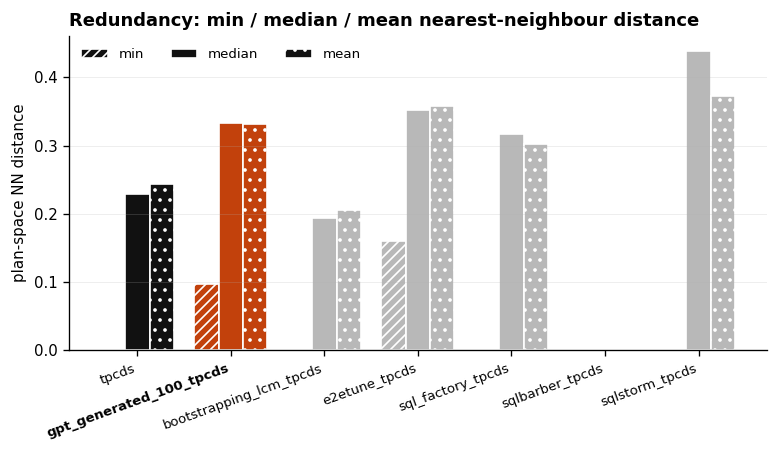

,min_nearest_neighbour_distance,median_nearest_neighbour_distance,mean_nearest_neighbour_distance,plan_graph_uniqueness_ratio,unique_plan_graph_count
w,,,,,
tpcds,0.000,0.228,0.243,0.848,84
gpt_generated_100_tpcds,0.097,0.333,0.332,1.000,100
bootstrapping_lcm_tpcds,0.000,0.194,0.206,0.950,95
e2etune_tpcds,0.160,0.352,0.358,1.000,100
sql_factory_tpcds,0.000,0.317,0.303,0.990,99
sqlbarber_tpcds,0.000,0.000,0.000,0.180,18
sqlstorm_tpcds,0.000,0.439,0.372,0.880,88


In [24]:
nn = ["min_nearest_neighbour_distance", "median_nearest_neighbour_distance",
      "mean_nearest_neighbour_distance"]
fig, ax = plt.subplots(figsize=(7.5, 3.4))
w, xs = 0.26, np.arange(len(ORDER) + 1)
rows = [REF] + ORDER
for k, (c, hatch) in enumerate(zip(nn, ["////", "", ".."])):
    ax.bar(xs + (k - 1) * w, df.loc[rows, c], w,
           color=[COL[r] for r in rows], hatch=hatch, edgecolor="white",
           label=c.replace("_nearest_neighbour_distance", ""))
ax.set_xticks(xs); ax.set_xticklabels(rows, rotation=20, ha="right", fontsize=8)
ax.get_xticklabels()[1].set_fontweight("bold")
ax.set_ylabel("plan-space NN distance")
ax.set_title("Redundancy: min / median / mean nearest-neighbour distance", loc="left", fontweight="bold")
ax.legend(frameon=False, fontsize=8, ncol=3)
ax.grid(axis="x", visible=False)
plt.show()

df.loc[rows, nn + ["plan_graph_uniqueness_ratio", "unique_plan_graph_count"]].round(3)

## 7. Summary table

In [25]:
summary = pd.DataFrame({
    "MARE (fidelity ↓)":        fidelity.reindex(GENS),
    "complexity L1 (↓)":        l1.reindex(GENS),
    "Vendi (diversity ↑)":      df.loc[GENS, "plan_graph_vendi_score"],
    "plan uniqueness (↑)":      df.loc[GENS, "plan_graph_uniqueness_ratio"],
    "min NN dist (↑)":          df.loc[GENS, "min_nearest_neighbour_distance"],
    "join-edge cov (↑)":        df.loc[GENS, "join_edge_coverage"],
    "column cov (↑)":           df.loc[GENS, "column_coverage"],
    "op n-grams (↑)":           df.loc[GENS, "unique_operator_ngram_count"],
})
summary.loc["real tpcds"] = [np.nan, np.nan,
    df.loc[REF, "plan_graph_vendi_score"], df.loc[REF, "plan_graph_uniqueness_ratio"],
    df.loc[REF, "min_nearest_neighbour_distance"], df.loc[REF, "join_edge_coverage"],
    df.loc[REF, "column_coverage"], df.loc[REF, "unique_operator_ngram_count"]]
summary.round(3)

,MARE (fidelity ↓),complexity L1 (↓),Vendi (diversity ↑),plan uniqueness (↑),min NN dist (↑),join-edge cov (↑),column cov (↑),op n-grams (↑)
w,,,,,,,,
bootstrapping_lcm_tpcds,0.691,0.385,11.643,0.950,0.000,0.683,0.593,128.0
e2etune_tpcds,0.776,0.325,26.170,1.000,0.160,0.951,0.685,203.0
gpt_generated_100_tpcds,0.603,0.157,27.192,1.000,0.097,0.951,0.508,138.0
sql_factory_tpcds,0.709,0.445,24.086,0.990,0.000,0.329,0.412,192.0
sqlbarber_tpcds,0.750,1.257,8.769,0.180,0.000,0.268,0.202,45.0
sqlstorm_tpcds,1.018,0.775,30.656,0.880,0.000,0.598,0.464,323.0
real tpcds,NaN,NaN,22.261,0.848,0.000,0.683,0.581,222.0
